# Evil Twin Attack Detection — Consolidated Model Comparison

Summary notebook building on `01_eda_and_prototyping.ipynb`. For each of the 9 models that were tuned separately (`tuning/knn.ipynb`, `tuning/random_forest.ipynb`, `tuning/logistic_regression.ipynb`, `tuning/svm.ipynb`, `tuning/extra_trees.ipynb`, `tuning/xgboost.ipynb`, `tuning/lightgbm.ipynb`, `tuning/catboost.ipynb`, `tuning/decision_tree.ipynb`), `GridSearchCV` is run **again** here — on both the original 4 features (`s1..s4`) and the 13 feature-engineered features (6 pairwise deltas + 3 aggregates: `mean_rssi`, `std_rssi`, `range_rssi`). The result is a single comparison table across all three tasks (Attack Detection, Point Prediction, Antenna Prediction) for all models at once.

**Evaluation method**: for each combination (model × feature set × task), we take `GridSearchCV(..., cv=5).best_score_` — the mean accuracy over 5 folds at the best found hyperparameters. This is the same metric that was called `full-CV` in the earlier notebooks.

GaussianNB/LDA/QDA are deliberately excluded — they have almost no hyperparameters to search over (this is already shown in `01_eda_and_prototyping.ipynb` as a baseline).

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

## 2. Load Dataset & Build ML Dataset

The same resampling pipeline as in `01_eda_and_prototyping.ipynb` — a synchronized vector `[s1, s2, s3, s4]` on a 5-second grid.

In [ ]:
from pathlib import Path

def _find_repo_root(marker="data/rssi_raw.csv"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} from {p}")

DATASET_PATH = _find_repo_root() / "data" / "rssi_raw.csv"

ANTENNA_MAP = {
    "none": 0,
    "Alfa ARS-N05": 1,
    "Alfa ARS-N19": 2,
    "Alfa APA-M25": 3,
    "AOSIYANT Yagi 16dBi": 4,
    "Logperiodic": 5,
    "Alfa APA-M04": 6,
}
ANTENNA_NAMES = {v: k for k, v in ANTENNA_MAP.items()}

raw = pd.read_csv(DATASET_PATH, parse_dates=["time"])

# Resample each sensor to a 5s grid, fill gaps with nearest value
sensors = {}
for i in range(1, 5):
    s = raw[raw["deviceID"] == f"sensor_{i}"][["time", "value"]].copy()
    s = s.set_index("time").sort_index()
    s = s.resample("5s").median()
    s = s.interpolate(method="nearest")
    s = s.rename(columns={"value": f"s{i}"})
    sensors[i] = s

# Inner join — keep only timestamps where all 4 sensors have data
df_pivot = sensors[1]
for i in range(2, 5):
    df_pivot = df_pivot.join(sensors[i], how="inner")

df_pivot = df_pivot.dropna().reset_index()

# Attach point/attack/antenna labels via nearest-time match against the raw labels
labels = raw[["time", "point", "attack", "antenna"]].drop_duplicates("time").sort_values("time")
dataset = pd.merge_asof(df_pivot.sort_values("time"), labels, on="time", direction="nearest")
dataset = dataset[["time", "s1", "s2", "s3", "s4", "point", "attack", "antenna"]]

print(f"Dataset shape: {dataset.shape}")
dataset.head()

Dataset shape: (2131, 8)


,time,s1,s2,s3,s4,point,attack,antenna
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0


## 3. Feature Engineering

The same feature engineering as in all `tuning/*_fe.ipynb` notebooks: 6 pairwise deltas between sensors + 3 aggregates (`mean_rssi`, `std_rssi`, `range_rssi`), computed instantly from a single `[s1,s2,s3,s4]` snapshot. `FEATURES_BASE` is the original 4 features, `FEATURES_FE` is all 13.

In [3]:
# ── Feature engineering: everything computable from a single [s1,s2,s3,s4] snapshot ──
sensor_cols = ["s1", "s2", "s3", "s4"]

# Pairwise signed deltas — relative signal geometry, less sensitive to overall power shifts
for a, b in [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]:
    dataset[f"d{a}{b}"] = dataset[f"s{a}"] - dataset[f"s{b}"]

# Row-wise aggregate shape of the RSSI vector across the 4 sensors
dataset["mean_rssi"]  = dataset[sensor_cols].mean(axis=1)
dataset["std_rssi"]   = dataset[sensor_cols].std(axis=1)
dataset["range_rssi"] = dataset[sensor_cols].max(axis=1) - dataset[sensor_cols].min(axis=1)

FEATURES_BASE = ["s1", "s2", "s3", "s4"]
FEATURES_FE = FEATURES_BASE + ["d12", "d13", "d14", "d23", "d24", "d34", "mean_rssi", "std_rssi", "range_rssi"]

print(f"Base features ({len(FEATURES_BASE)}): {FEATURES_BASE}")
print(f"FE features ({len(FEATURES_FE)}): {FEATURES_FE}")
dataset.head()

Base features (4): ['s1', 's2', 's3', 's4']
FE features (13): ['s1', 's2', 's3', 's4', 'd12', 'd13', 'd14', 'd23', 'd24', 'd34', 'mean_rssi', 'std_rssi', 'range_rssi']


,time,s1,s2,s3,s4,point,attack,antenna,d12,d13,d14,d23,d24,d34,mean_rssi,std_rssi,range_rssi
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0,-2.0,6.0,4.0,8.0,6.0,-2.0,-58.00,3.651484,8.0
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0,-1.0,9.0,5.0,10.0,6.0,-4.0,-58.25,4.645787,10.0
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0,-3.0,-1.0,4.0,2.0,7.0,5.0,-56.00,2.943920,7.0
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0,-2.0,-1.0,3.0,1.0,5.0,4.0,-56.00,2.160247,5.0
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0,-1.0,2.0,6.0,3.0,7.0,4.0,-56.75,3.095696,7.0


## 4. Cascade Task Data

Attack Detection is trained on the full dataset; Point/Antenna Prediction only on attack samples. The `X` matrices are built separately for each feature set (`Base`/`FE`) in Section 6.

In [4]:
attack_mask = dataset["attack"] == 1

y_attack  = dataset["attack"]
y_point   = dataset.loc[attack_mask, "point"]
y_antenna = dataset.loc[attack_mask, "antenna"]

print(f"Attack Detection:   {len(dataset)} rows, {y_attack.nunique()} classes")
print(f"Point Prediction:   {attack_mask.sum()} rows, {y_point.nunique()} classes")
print(f"Antenna Prediction: {attack_mask.sum()} rows, {y_antenna.nunique()} classes")

Attack Detection:   2131 rows, 2 classes
Point Prediction:   571 rows, 8 classes
Antenna Prediction: 571 rows, 6 classes


## 5. Model & Hyperparameter Grid Definitions

The same `param_grid`s as in the individual `tuning/*.ipynb` notebooks — so the numbers here are comparable to the earlier notebooks. `scale=True` means a `StandardScaler` in the pipeline (needed for KNN/SVM/LogReg — distance-based and gradient-based models). XGBoost is handled separately below due to its 0-based label requirement and the different `eval_metric` for binary vs. multiclass tasks.

In [5]:
MODEL_CONFIGS = {
    "Logistic Regression": {
        "make": lambda: LogisticRegression(solver="saga", max_iter=5000, random_state=42),
        "grid": {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000], "penalty": ["l1", "l2"], "class_weight": [None, "balanced"]},
        "scale": True,
    },
    "SVM (RBF)": {
        # probability=False here — we only need best_score_ (accuracy), not predict_proba,
        # and probability=True triggers an expensive internal Platt-scaling CV per fit.
        "make": lambda: SVC(kernel="rbf", probability=False, random_state=42),
        "grid": {"C": [0.01, 0.1, 1, 10, 100, 1000], "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10]},
        "scale": True,
    },
    "KNN": {
        "make": lambda: KNeighborsClassifier(),
        "grid": {"n_neighbors": list(range(1, 26)), "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan", "chebyshev"]},
        "scale": True,
    },
    "Decision Tree": {
        "make": lambda: DecisionTreeClassifier(random_state=42),
        "grid": {"max_depth": [3, 5, 8, 10, 15, None], "min_samples_split": [2, 5, 10, 20], "min_samples_leaf": [1, 2, 5, 10], "criterion": ["gini", "entropy"]},
        "scale": False,
    },
    "Random Forest": {
        "make": lambda: RandomForestClassifier(random_state=42),
        "grid": {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20, 30], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]},
        "scale": False,
    },
    "Extra Trees": {
        "make": lambda: ExtraTreesClassifier(random_state=42),
        "grid": {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20, 30], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]},
        "scale": False,
    },
    "XGBoost": {
        "make": None,  # handled specially in run_xgb_search — needs eval_metric + 0-based labels
        "grid": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1, 0.3], "subsample": [0.8, 1.0]},
        "scale": False,
    },
    "LightGBM": {
        "make": lambda: LGBMClassifier(random_state=42, verbosity=-1),
        "grid": {"n_estimators": [100, 200, 300], "max_depth": [-1, 3, 5, 7], "learning_rate": [0.01, 0.1, 0.3], "num_leaves": [15, 31, 63]},
        "scale": False,
    },
    "CatBoost": {
        "make": lambda: CatBoostClassifier(random_state=42, verbose=False),
        "grid": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7, 9], "learning_rate": [0.01, 0.1, 0.3], "l2_leaf_reg": [1, 3, 10]},
        "scale": False,
    },
}

print(f"Models to tune ({len(MODEL_CONFIGS)}): {list(MODEL_CONFIGS.keys())}")

Models to tune (9): ['Logistic Regression', 'SVM (RBF)', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']


In [6]:
def run_grid_search(cfg, X, y):
    if cfg["scale"]:
        pipe = Pipeline([("scaler", StandardScaler()), ("model", cfg["make"]())])
        grid = {f"model__{k}": v for k, v in cfg["grid"].items()}
    else:
        pipe = cfg["make"]()
        grid = cfg["grid"]
    search = GridSearchCV(pipe, grid, cv=5, scoring="accuracy", n_jobs=-1)
    search.fit(X, y)
    return search.best_score_, search.best_params_


def run_xgb_search(grid, X, y, is_multiclass):
    # XGBoost needs 0-based labels for multiclass and a matching eval_metric.
    # Shifting labels by a constant doesn't change accuracy — it's a bijective relabeling.
    y_use = y - 1 if is_multiclass else y
    eval_metric = "mlogloss" if is_multiclass else "logloss"
    search = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric=eval_metric),
        grid, cv=5, scoring="accuracy", n_jobs=-1,
    )
    search.fit(X, y_use)
    return search.best_score_, search.best_params_

## 6. Main Search Loop

9 models × 2 feature sets (Base/FE) × 3 tasks = 54 `GridSearchCV` runs. This is the longest-running cell in the notebook — it takes a few minutes.

In [7]:
FEATURE_SETS = {"Base (4)": FEATURES_BASE, "FE (13)": FEATURES_FE}

# (which_X, y, is_multiclass) — which_X selects between the full dataset and the attack-only subset
TASKS_TEMPLATE = {
    "Attack Detection":   ("full", y_attack, False),
    "Point Prediction":   ("attack_only", y_point, True),
    "Antenna Prediction": ("attack_only", y_antenna, True),
}

results = []

for fs_label, feat_cols in FEATURE_SETS.items():
    X_full        = dataset[feat_cols]
    X_attack_only = dataset.loc[attack_mask, feat_cols]

    for task_name, (which_X, y, is_multiclass) in TASKS_TEMPLATE.items():
        Xd = X_full if which_X == "full" else X_attack_only

        for model_name, cfg in MODEL_CONFIGS.items():
            if model_name == "XGBoost":
                score, params = run_xgb_search(cfg["grid"], Xd, y, is_multiclass)
            else:
                score, params = run_grid_search(cfg, Xd, y)

            results.append({
                "Model": model_name,
                "Feature Set": fs_label,
                "Task": task_name,
                "CV Accuracy": score,
                "Best Params": params,
            })
            print(f"[{fs_label:>8}] {model_name:<20} {task_name:<20} cv={score:.3f}")

results_df = pd.DataFrame(results)
print(f"\nTotal runs: {len(results_df)}")

[Base (4)] Logistic Regression  Attack Detection     cv=0.988
[Base (4)] SVM (RBF)            Attack Detection     cv=0.989
[Base (4)] KNN                  Attack Detection     cv=0.990
[Base (4)] Decision Tree        Attack Detection     cv=0.990
[Base (4)] Random Forest        Attack Detection     cv=0.989
[Base (4)] Extra Trees          Attack Detection     cv=0.989
[Base (4)] XGBoost              Attack Detection     cv=0.988
[Base (4)] LightGBM             Attack Detection     cv=0.988
[Base (4)] CatBoost             Attack Detection     cv=0.991
[Base (4)] Logistic Regression  Point Prediction     cv=0.725
[Base (4)] SVM (RBF)            Point Prediction     cv=0.794
[Base (4)] KNN                  Point Prediction     cv=0.795
[Base (4)] Decision Tree        Point Prediction     cv=0.736
[Base (4)] Random Forest        Point Prediction     cv=0.816
[Base (4)] Extra Trees          Point Prediction     cv=0.820
[Base (4)] XGBoost              Point Prediction     cv=0.785
[Base (4

/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[Base (4)] XGBoost              Antenna Prediction   cv=0.438
[Base (4)] LightGBM             Antenna Prediction   cv=0.434
[Base (4)] CatBoost             Antenna Prediction   cv=0.471


/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/stealth/opt/anaconda3/lib/python3

[ FE (13)] Logistic Regression  Attack Detection     cv=0.987
[ FE (13)] SVM (RBF)            Attack Detection     cv=0.989
[ FE (13)] KNN                  Attack Detection     cv=0.990
[ FE (13)] Decision Tree        Attack Detection     cv=0.988
[ FE (13)] Random Forest        Attack Detection     cv=0.989
[ FE (13)] Extra Trees          Attack Detection     cv=0.989
[ FE (13)] XGBoost              Attack Detection     cv=0.990
[ FE (13)] LightGBM             Attack Detection     cv=0.989
[ FE (13)] CatBoost             Attack Detection     cv=0.990
[ FE (13)] Logistic Regression  Point Prediction     cv=0.750
[ FE (13)] SVM (RBF)            Point Prediction     cv=0.802
[ FE (13)] KNN                  Point Prediction     cv=0.811
[ FE (13)] Decision Tree        Point Prediction     cv=0.781
[ FE (13)] Random Forest        Point Prediction     cv=0.822
[ FE (13)] Extra Trees          Point Prediction     cv=0.825
[ FE (13)] XGBoost              Point Prediction     cv=0.797
[ FE (13

## 7. Full Comparison Table

All 54 results as a pivoted table: rows are models, columns are (task, feature set).

In [8]:
TASKS_ORDER = ["Attack Detection", "Point Prediction", "Antenna Prediction"]

comparison = results_df.pivot_table(index="Model", columns=["Task", "Feature Set"], values="CV Accuracy")
comparison = comparison.reindex(list(MODEL_CONFIGS.keys()))
comparison = comparison[[(t, fs) for t in TASKS_ORDER for fs in ["Base (4)", "FE (13)"]]]

print("=" * 100)
print("Full Comparison — 5-fold CV Accuracy (Base = 4 raw features, FE = 13 engineered features)")
print("=" * 100)
print(comparison.round(3).to_string())

Full Comparison — 5-fold CV Accuracy (Base = 4 raw features, FE = 13 engineered features)
Task                Attack Detection         Point Prediction         Antenna Prediction        
Feature Set                 Base (4) FE (13)         Base (4) FE (13)           Base (4) FE (13)
Model                                                                                           
Logistic Regression            0.988   0.987            0.725   0.750              0.364   0.364
SVM (RBF)                      0.989   0.989            0.794   0.802              0.454   0.466
KNN                            0.990   0.990            0.795   0.811              0.468   0.464
Decision Tree                  0.990   0.988            0.736   0.781              0.420   0.431
Random Forest                  0.989   0.989            0.816   0.822              0.441   0.489
Extra Trees                    0.989   0.989            0.820   0.825              0.471   0.491
XGBoost                        0.988 

### 7.1 Feature Engineering Effect (FE − Base)

A positive number means feature engineering improved CV accuracy for that model and task.

In [9]:
delta_rows = []
for model in MODEL_CONFIGS:
    row = {"Model": model}
    for task in TASKS_ORDER:
        base = results_df[(results_df.Model == model) & (results_df.Task == task) & (results_df["Feature Set"] == "Base (4)")]["CV Accuracy"].iloc[0]
        fe   = results_df[(results_df.Model == model) & (results_df.Task == task) & (results_df["Feature Set"] == "FE (13)")]["CV Accuracy"].iloc[0]
        row[f"{task} Δ"] = fe - base
    delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows).set_index("Model").round(3)
print("=" * 70)
print("Feature Engineering Effect (FE CV accuracy − Base CV accuracy)")
print("=" * 70)
print(delta_df.to_string())

Feature Engineering Effect (FE CV accuracy − Base CV accuracy)
                     Attack Detection Δ  Point Prediction Δ  Antenna Prediction Δ
Model                                                                            
Logistic Regression              -0.001               0.024                 0.000
SVM (RBF)                        -0.000               0.009                 0.012
KNN                              -0.000               0.016                -0.004
Decision Tree                    -0.001               0.045                 0.011
Random Forest                     0.000               0.005                 0.047
Extra Trees                      -0.000               0.005                 0.019
XGBoost                           0.001               0.012                 0.042
LightGBM                          0.000               0.009                 0.030
CatBoost                         -0.001               0.002                 0.000


## 8. Visualization

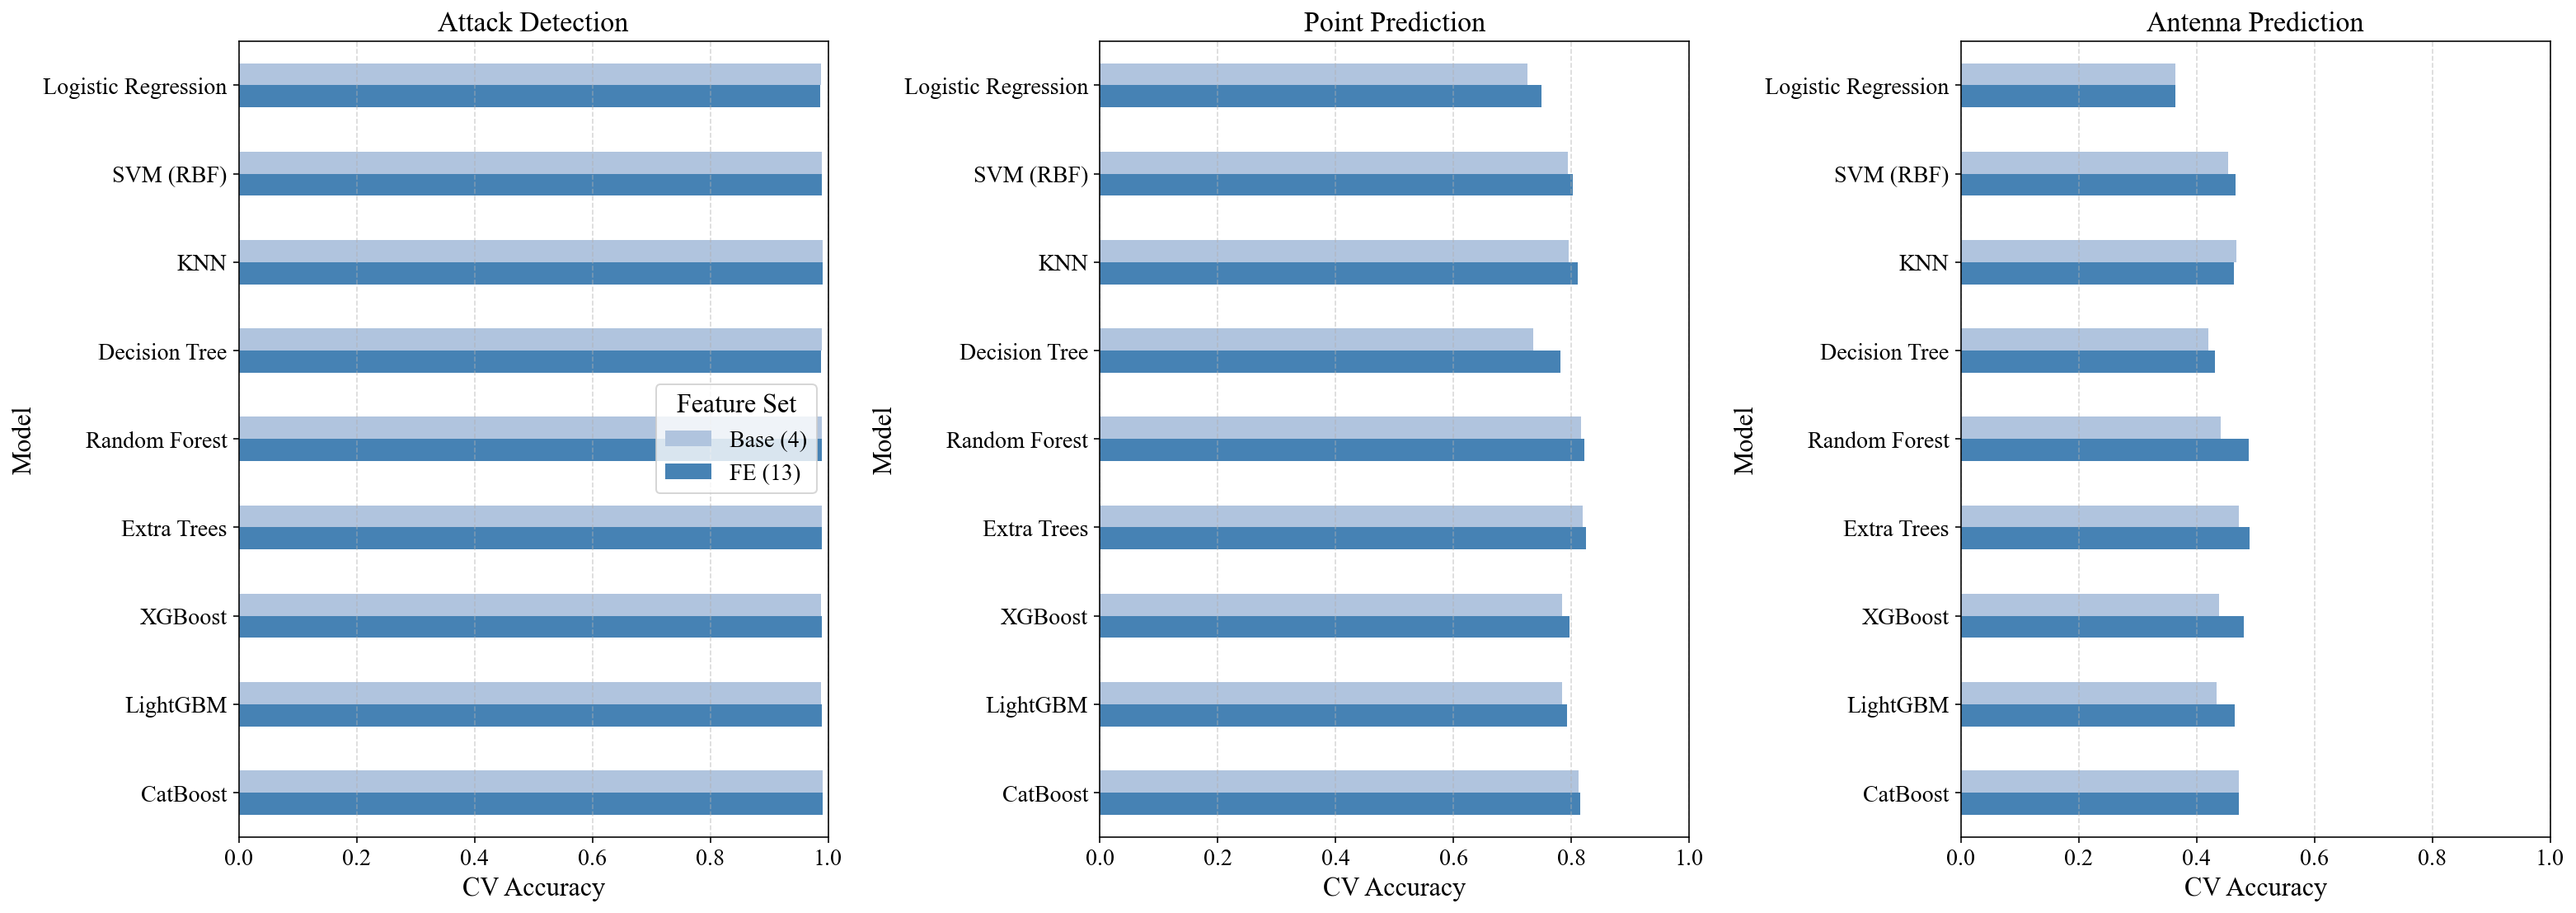

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, task in zip(axes, TASKS_ORDER):
    sub = results_df[results_df.Task == task]
    pivot_task = sub.pivot(index="Model", columns="Feature Set", values="CV Accuracy")
    pivot_task = pivot_task.reindex(list(MODEL_CONFIGS.keys()))[["Base (4)", "FE (13)"]]

    pivot_task.plot(kind="barh", ax=ax, color=["#B0C4DE", "#4682B4"], legend=False)
    ax.set_title(task)
    ax.set_xlabel("CV Accuracy")
    ax.set_xlim(0, 1.0)
    ax.invert_yaxis()
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Feature Set", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

## 9. Winner Summary

In [11]:
print("=" * 70)
print("Winner per task (best CV accuracy across all models × feature sets)")
print("=" * 70)
for task in TASKS_ORDER:
    sub = results_df[results_df.Task == task].sort_values("CV Accuracy", ascending=False)
    best = sub.iloc[0]
    print(f"{task:<22} {best.Model} ({best['Feature Set']}) — {best['CV Accuracy']:.3f}")

# Overall ranking: for each model/task take its best feature-set score, then average across the 3 tasks
best_per_model_task = results_df.loc[results_df.groupby(["Model", "Task"])["CV Accuracy"].idxmax()]
avg_per_model = best_per_model_task.groupby("Model")["CV Accuracy"].mean().sort_values(ascending=False)

print()
print("=" * 70)
print("Overall ranking — mean of best-feature-set CV accuracy across the 3 tasks")
print("=" * 70)
print(avg_per_model.round(3).to_string())

Winner per task (best CV accuracy across all models × feature sets)
Attack Detection       CatBoost (Base (4)) — 0.991
Point Prediction       Extra Trees (FE (13)) — 0.825
Antenna Prediction     Extra Trees (FE (13)) — 0.491

Overall ranking — mean of best-feature-set CV accuracy across the 3 tasks
Model
Extra Trees            0.768
Random Forest          0.766
CatBoost               0.759
KNN                    0.756
XGBoost                0.756
SVM (RBF)              0.752
LightGBM               0.749
Decision Tree          0.734
Logistic Regression    0.701
